In [1]:
#Modelling Phase

In [2]:
# ============================================================
# PROJECT 1: Customer Churn Prediction
# Phase 3: Modeling + Business Intelligence Layer
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score)
from sklearn.pipeline import Pipeline
import xgboost as xgb

# ── 1. LOAD ENGINEERED DATA ───────────────────────────────────
df = pd.read_csv('telco_engineered.csv')

# Rebuild value_tier if it was saved as string (pd.qcut doesn't survive CSV well)
df['value_tier'] = pd.qcut(df['cltv'], q=3,
                            labels=['Low Value', 'Mid Value', 'High Value'])

print("Shape:", df.shape)
print("Churn rate:", df['churn_value'].mean().round(3))

Shape: (7043, 45)
Churn rate: 0.265


In [3]:
# ── 2. DEFINE FEATURE SET ─────────────────────────────────────
model_features = [
    'tenure_months', 'monthly_charges', 'total_charges', 'cltv',
    'service_bundle_score', 'gender_encoded', 'senior_citizen',
    'partner', 'dependents', 'phone_service', 'multiple_lines',
    'online_security', 'online_backup', 'device_protection',
    'tech_support', 'streaming_tv', 'streaming_movies',
    'paperless_billing', 'high_arpu', 'risk_flag', 'contract_encoded',
]

# Add one-hot columns dynamically (safer than hardcoding names)
payment_cols  = [c for c in df.columns if c.startswith('payment_method_')]
internet_cols = [c for c in df.columns if c.startswith('internet_service_')]
model_features += payment_cols + internet_cols

target = 'churn_value'

X = df[model_features]
y = df[target]

print(f"\nFeatures used : {len(model_features)}")
print(f"Payment cols  : {payment_cols}")
print(f"Internet cols : {internet_cols}")


Features used : 28
Payment cols  : ['payment_method_Bank transfer (automatic)', 'payment_method_Credit card (automatic)', 'payment_method_Electronic check', 'payment_method_Mailed check']
Internet cols : ['internet_service_DSL', 'internet_service_Fiber optic', 'internet_service_No']


In [4]:
# ── 3. TRAIN/TEST SPLIT ───────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # preserves 26.5% churn ratio in both splits
)

print(f"\nTrain size : {X_train.shape[0]:,} | Churn rate: {y_train.mean():.1%}")
print(f"Test size  : {X_test.shape[0]:,} | Churn rate: {y_test.mean():.1%}")


Train size : 5,634 | Churn rate: 26.5%
Test size  : 1,409 | Churn rate: 26.5%


In [5]:
# ── 4. CLASS IMBALANCE — CHECK & STRATEGY ────────────────────
neg, pos = y_train.value_counts()
scale_pos_weight = neg / pos  # Used by XGBoost

print(f"\nClass imbalance ratio : {scale_pos_weight:.2f}:1 (non-churn:churn)")
print("Strategy: class_weight='balanced' for LR & RF, scale_pos_weight for XGB")


Class imbalance ratio : 2.77:1 (non-churn:churn)
Strategy: class_weight='balanced' for LR & RF, scale_pos_weight for XGB


In [6]:
# ── 5. BUILD THREE MODELS ─────────────────────────────────────

# --- Model 1: Logistic Regression (baseline) ---
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),          # LR needs scaling, tree models don't
    ('model',  LogisticRegression(
                   class_weight='balanced',
                   max_iter=1000,
                   random_state=42))
])

# --- Model 2: Random Forest ---
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=20,       # prevents overfitting on small leaf nodes
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# --- Model 3: XGBoost ---
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,   # handles imbalance
    eval_metric='auc',
    random_state=42,
    verbosity=0
)

models = {
    'Logistic Regression': lr_pipe,
    'Random Forest':       rf_model,
    'XGBoost':             xgb_model
}

In [7]:
# ── 6. CROSS-VALIDATION COMPARISON ───────────────────────────
print("\n=== CROSS-VALIDATION RESULTS (5-fold, ROC-AUC) ===")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train,
                             cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:25s} → AUC: {scores.mean():.4f} ± {scores.std():.4f}")


=== CROSS-VALIDATION RESULTS (5-fold, ROC-AUC) ===
Logistic Regression       → AUC: 0.8593 ± 0.0128
Random Forest             → AUC: 0.8612 ± 0.0100
XGBoost                   → AUC: 0.8552 ± 0.0118


In [8]:
# ── 7. TRAIN FINAL MODELS & EVALUATE ON TEST SET ─────────────
print("\n=== TEST SET PERFORMANCE ===")

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred      = model.predict(X_test)
    y_prob      = model.predict_proba(X_test)[:, 1]
    auc         = roc_auc_score(y_test, y_prob)
    avg_prec    = average_precision_score(y_test, y_prob)
    results[name] = {'model': model, 'y_pred': y_pred,
                     'y_prob': y_prob, 'auc': auc, 'avg_prec': avg_prec}
    print(f"\n{name}")
    print(f"  ROC-AUC            : {auc:.4f}")
    print(f"  Avg Precision      : {avg_prec:.4f}")
    print(classification_report(y_test, y_pred,
                                target_names=['No Churn','Churn']))


=== TEST SET PERFORMANCE ===

Logistic Regression
  ROC-AUC            : 0.8472
  Avg Precision      : 0.6351
              precision    recall  f1-score   support

    No Churn       0.91      0.72      0.81      1035
       Churn       0.51      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409


Random Forest
  ROC-AUC            : 0.8545
  Avg Precision      : 0.6591
              precision    recall  f1-score   support

    No Churn       0.91      0.76      0.83      1035
       Churn       0.55      0.78      0.64       374

    accuracy                           0.77      1409
   macro avg       0.73      0.77      0.74      1409
weighted avg       0.81      0.77      0.78      1409


XGBoost
  ROC-AUC            : 0.8462
  Avg Precision      : 0.6521
              precision    recall  f1-score   support

    No Churn       0.90      0.77   

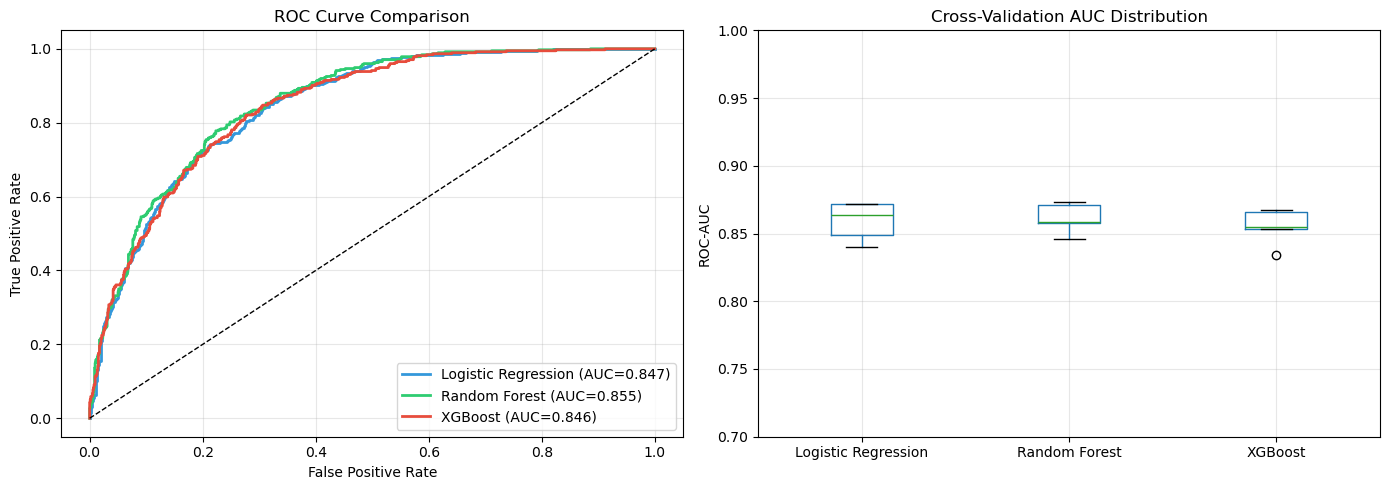

In [9]:
# ── 8. ROC CURVE COMPARISON PLOT ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curves
ax = axes[0]
colors = ['#3498db', '#2ecc71', '#e74c3c']
for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.3f})", 
            color=color, lw=2)
ax.plot([0,1],[0,1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison')
ax.legend()
ax.grid(alpha=0.3)

# CV Score Distribution
ax = axes[1]
cv_df = pd.DataFrame(cv_results)
cv_df.boxplot(ax=ax)
ax.set_title('Cross-Validation AUC Distribution')
ax.set_ylabel('ROC-AUC')
ax.set_ylim(0.7, 1.0)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

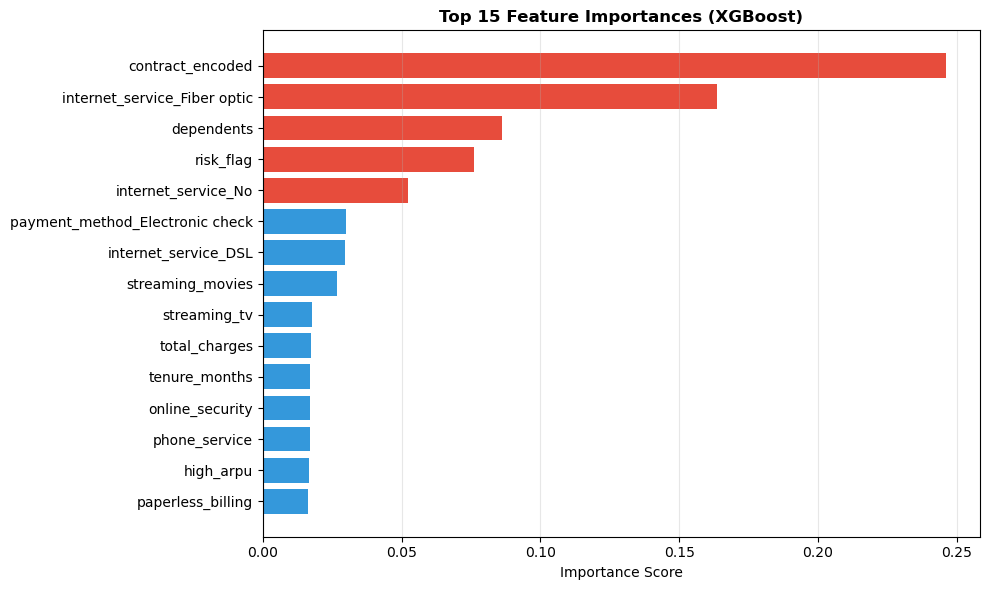


Top 10 features:
                         feature  importance
               contract_encoded    0.246084
   internet_service_Fiber optic    0.163602
                     dependents    0.086241
                      risk_flag    0.076093
            internet_service_No    0.052327
payment_method_Electronic check    0.030025
           internet_service_DSL    0.029498
               streaming_movies    0.026889
                   streaming_tv    0.017723
                  total_charges    0.017358


In [10]:
# ── 9. FEATURE IMPORTANCE (XGBoost) ──────────────────────────
# XGBoost usually wins — use it for feature importance
xgb_model_fit = results['XGBoost']['model']

importance_df = pd.DataFrame({
    'feature':    model_features,
    'importance': xgb_model_fit.feature_importances_
}).sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if i < 5 else '#3498db' for i in range(len(importance_df))]
ax.barh(importance_df['feature'][::-1], 
        importance_df['importance'][::-1], color=colors[::-1])
ax.set_title('Top 15 Feature Importances (XGBoost)', fontweight='bold')
ax.set_xlabel('Importance Score')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 features:\n", importance_df.head(10).to_string(index=False))

In [11]:
# ── 10. BUSINESS LAYER: CHURN PROBABILITY PER CUSTOMER ───────
# Use the best model (XGBoost) to score every customer
best_model = results['XGBoost']['model']

df['churn_probability'] = best_model.predict_proba(X)[:, 1]

# Classify risk tier based on predicted probability
df['churn_risk_tier'] = pd.cut(
    df['churn_probability'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

print("\nRisk tier distribution:\n", 
      df['churn_risk_tier'].value_counts())


Risk tier distribution:
 churn_risk_tier
Low Risk       3690
High Risk      2176
Medium Risk    1177
Name: count, dtype: int64


In [12]:
# ── 12. RETENTION SPEND RECOMMENDATION ───────────────────────
# Rule: retention spend should not exceed expected revenue saved
# Assumption: 40% of targeted customers can be saved with intervention
SAVE_RATE         = 0.40
AVG_RETENTION_COST = 50   # $ per customer contacted (adjust to reality)

print("\n=== RETENTION SPEND RECOMMENDATION ===\n")
print(f"{'Segment':<35} {'At-Risk $':>12} {'Saveable $':>12} {'Max Spend':>12} {'ROI':>8}")
print("-" * 85)

priority_segments = df[df['churn_risk_tier'] == 'High Risk'].groupby('value_tier')

for tier, group in priority_segments:
    monthly_rev    = group['monthly_charges'].sum()
    annual_rev     = monthly_rev * 12
    saveable_rev   = annual_rev * SAVE_RATE
    n_customers    = len(group)
    retention_cost = n_customers * AVG_RETENTION_COST
    roi            = (saveable_rev - retention_cost) / retention_cost * 100

    print(f"{'High Risk | ' + str(tier):<35} "
          f"${annual_rev:>11,.0f} "
          f"${saveable_rev:>11,.0f} "
          f"${retention_cost:>11,.0f} "
          f"{roi:>7.0f}%")


=== RETENTION SPEND RECOMMENDATION ===

Segment                                At-Risk $   Saveable $    Max Spend      ROI
-------------------------------------------------------------------------------------
High Risk | Low Value               $    877,698 $    351,079 $     48,700     621%
High Risk | Mid Value               $    615,588 $    246,235 $     33,350     638%
High Risk | High Value              $    505,184 $    202,074 $     26,750     655%


In [13]:
# ── 13. SAVE FINAL SCORED DATASET ────────────────────────────
output_cols = ['customer_id', 'monthly_charges', 'total_charges', 'cltv',
               'tenure_months', 'contract', 'churn_value', 'churn_probability',
               'churn_risk_tier', 'value_tier', 'service_bundle_score',
               'risk_flag', 'churn_reason']

# Keep only cols that exist
output_cols = [c for c in output_cols if c in df.columns]
df[output_cols].to_csv('telco_scored.csv', index=False)

print("\n✓ Saved: telco_scored.csv")
print(f"  Total customers scored : {len(df):,}")
print(f"  High Risk + High Value : "
      f"{len(df[(df['churn_risk_tier']=='High Risk') & (df['value_tier']=='High Value')]):,}")
print(f"\nPhase 3 complete. Ready for Power BI.")


✓ Saved: telco_scored.csv
  Total customers scored : 7,043
  High Risk + High Value : 535

Phase 3 complete. Ready for Power BI.
